In [71]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import joblib
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.base import clone

sys.path.append(str(Path("..").resolve()))

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
PROCESSED_DIR = Path("../data/interim")
MODEL_DIR = Path("../models")
REPORT_DIR = Path("../reports")

In [72]:
X_train_pre: pd.DataFrame = pd.read_csv(PROCESSED_DIR / "X_train_pre.csv", index_col=0)
X_val_pre: pd.DataFrame   = pd.read_csv(PROCESSED_DIR / "X_val_pre.csv",   index_col=0)
X_test_pre: pd.DataFrame  = pd.read_csv(PROCESSED_DIR / "X_test_pre.csv",  index_col=0)

y_train: pd.Series = pd.read_csv(PROCESSED_DIR / "y_train.csv", index_col=0).squeeze()
y_val: pd.Series   = pd.read_csv(PROCESSED_DIR / "y_val.csv",   index_col=0).squeeze()

feature_pipeline: SkPipeline = joblib.load(MODEL_DIR / "feature_pipeline.joblib")
imputer_ct: ColumnTransformer = joblib.load(MODEL_DIR / "imputer_ct.joblib")
transform_ct: ColumnTransformer = joblib.load(MODEL_DIR / "transform_ct.joblib")

print(f"Successfully loaded data!")
print(f"Train: {X_train_pre.shape} | Val: {X_val_pre.shape} | Test: {X_test_pre.shape}")
print(f"Train cols: {X_train_pre.columns.tolist()}")

Successfully loaded data!
Train: (112560, 32) | Val: (28140, 32) | Test: (93800, 32)
Train cols: ['Gender', 'Age', 'Working Professional or Student', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Academic Pressure_is_missing', 'Work Pressure_is_missing', 'CGPA_is_missing', 'Study Satisfaction_is_missing', 'Job Satisfaction_is_missing', 'Dietary Habits_is_missing', 'Financial Stress_is_missing', 'Total Pressure', 'Max Pressure', 'Total Satisfaction', 'Min Satisfaction', 'Pressure_Satisfaction_Gap', 'High_Working_Hours_Flag', 'High_Financial_Stress_Flag', 'Is_Young_Adult', 'Suicide_Pressure_Interaction']


In [73]:
models: dict[str, object] = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
}

In [74]:
def evaluate_model(
    name: str, model: object, X_val: pd.DataFrame, y_val: pd.Series) -> tuple[dict[str, object], np.ndarray]:
    """
    Generate predictions and compute all evaluation metrics for a model.

    Returns:
        tuple: (metrics_dict, y_pred)
        - metrics_dict: A dictionary containing the model name and metric scores.
        - y_pred: Predicted labels, returned for reuse to avoid calling predict() twice.
    """
    y_pred: np.ndarray  = model.predict(X_val)
    y_proba: np.ndarray = model.predict_proba(X_val)[:, 1]

    metrics: dict[str, object] = {
        "model":     name,
        "accuracy":  accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall":    recall_score(y_val, y_pred, zero_division=0),
        "f1":        f1_score(y_val, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_val, y_proba),
    }
    return metrics, y_pred

In [75]:
num_cols = list(imputer_ct.transformers[0][2])
cat_cols = list(imputer_ct.transformers[1][2])

base_cat_indices = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

binary_cols_in_num = (
    ["Profession", "Degree"]
    + [col for col in num_cols if col.endswith("_is_missing")]
    + ["High_Working_Hours_Flag", "High_Financial_Stress_Flag", "Is_Young_Adult"]
)

extra_cat_indices = [num_cols.index(col) for col in binary_cols_in_num if col in num_cols]

new_cat_indices = sorted(base_cat_indices + extra_cat_indices)
print(f"Categorical column indices for SMOTENC: {new_cat_indices}")
print(f"Total categorical features: {len(new_cat_indices)}")

Categorical column indices for SMOTENC: [1, 7, 10, 11, 12, 13, 14, 15, 16, 22, 23, 24, 26, 27, 28, 29, 30, 31]
Total categorical features: 18


In [76]:
results: list[dict] = []
fitted_models: dict[str, SkPipeline] = {}
reports: dict[str, str] = {}

for name, classifier in models.items():
    print(f"Training: {name}...")

    train_pipeline = ImbPipeline(steps=[
        ("imputer", imputer_ct),
        ("smotenc", SMOTENC(categorical_features=new_cat_indices, random_state=RANDOM_STATE, k_neighbors=5)),
        ("transformer", transform_ct),
        ("classifier", classifier),
    ])

    train_pipeline.fit(X_train_pre, y_train)

    inference_pipeline = SkPipeline(steps=[
        ("imputer", train_pipeline.named_steps["imputer"]),
        ("transformer", train_pipeline.named_steps["transformer"]),
        ("classifier", train_pipeline.named_steps["classifier"]),
    ])
    
    fitted_models[name] = inference_pipeline

    metrics, y_pred = evaluate_model(name, inference_pipeline, X_val_pre, y_val)

    results.append(metrics)
    reports[name] = classification_report(
        y_val,
        y_pred,
        target_names=["Non-Depression (0)", "Depression (1)"]
    )

    print(f"{name}: F1={metrics['f1']:.4f} | ROC-AUC={metrics['roc_auc']:.4f}")

print("Training completely!")

Training: Logistic Regression...
Logistic Regression: F1=0.8048 | ROC-AUC=0.9721
Training: Decision Tree...
Decision Tree: F1=0.7972 | ROC-AUC=0.9609
Training: Random Forest...
Random Forest: F1=0.8206 | ROC-AUC=0.9717
Training: XGBoost...
XGBoost: F1=0.8284 | ROC-AUC=0.9735
Training completely!


In [77]:
results_df: pd.DataFrame = (
    pd.DataFrame(results)
    .sort_values(by=["f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

styled = results_df.style.format({
    "accuracy":  "{:.4f}",
    "precision": "{:.4f}",
    "recall":    "{:.4f}",
    "f1":        "{:.4f}",
    "roc_auc":   "{:.4f}",
}).highlight_max(
    subset=["accuracy", "precision", "recall", "f1", "roc_auc"],
    color="lightgreen",
)

display(styled)

best_name: str = results_df.loc[0, "model"]
print(f"\nBest model based on F1-Score: {best_name}")
print(f"\nClassification Report:\n{reports[best_name]}")

,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.9342,0.7876,0.8737,0.8284,0.9735
1,Random Forest,0.9306,0.7734,0.8739,0.8206,0.9717
2,Logistic Regression,0.9196,0.7198,0.9126,0.8048,0.9721
3,Decision Tree,0.9196,0.7357,0.8699,0.7972,0.9609



Best model based on F1-Score: XGBoost

Classification Report:
                    precision    recall  f1-score   support

Non-Depression (0)       0.97      0.95      0.96     23027
    Depression (1)       0.79      0.87      0.83      5113

          accuracy                           0.93     28140
         macro avg       0.88      0.91      0.89     28140
      weighted avg       0.94      0.93      0.94     28140



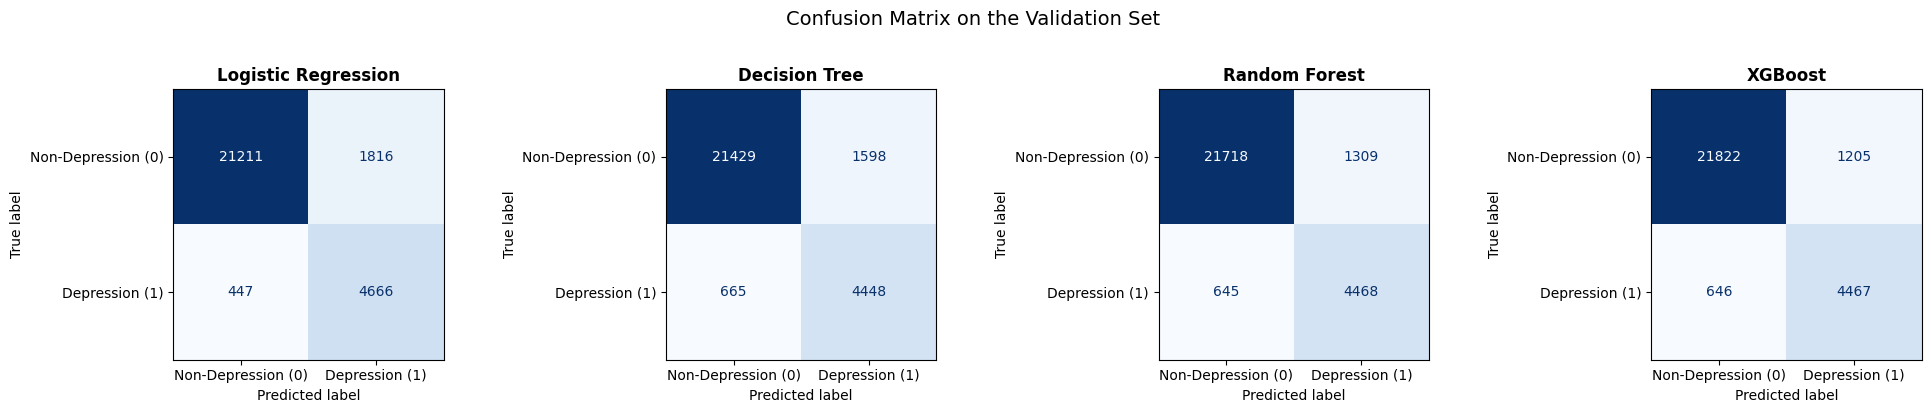

In [78]:
n_models: int = len(fitted_models)
fig, axes = plt.subplots(
    nrows=1, ncols=n_models,
    figsize=(5 * n_models, 4)
)

if n_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred: np.ndarray = model.predict(X_val_pre)
    cm: np.ndarray = confusion_matrix(y_val, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Depression (0)", "Depression (1)"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12, fontweight="bold")

plt.suptitle("Confusion Matrix on the Validation Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()

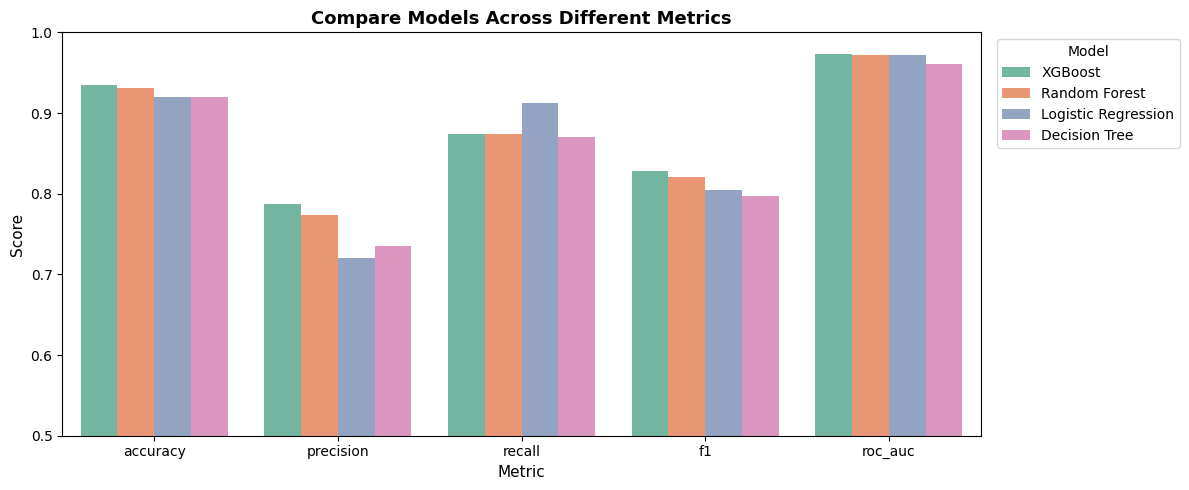

In [79]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]

plot_df: pd.DataFrame = results_df.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model", palette="Set2", ax=ax)

ax.set_ylim(0.5, 1.0)
ax.set_title("Compare Models Across Different Metrics", fontsize=13, fontweight="bold")
ax.set_xlabel("Metric", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig(REPORT_DIR / "model_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

In [80]:
MODEL_DIR.mkdir(exist_ok=True)

print("Saving final end-to-end pipelines...")

for name, inference_pipeline in fitted_models.items():
    # Raw data -> feature_pipeline -> imputer -> transformer -> classifier
    full_pipeline = SkPipeline(steps=[
        ("feature_engineering", feature_pipeline),
        ("inference", inference_pipeline)
    ])
    
    filename = f"model_{name.lower().replace(' ', '_')}.joblib"
    joblib.dump(full_pipeline, MODEL_DIR / filename)
    print(f"Saved: {filename}")

print(f"\nAll models are saved into folder: {MODEL_DIR.resolve()}")

Saving final end-to-end pipelines...
Saved: model_logistic_regression.joblib
Saved: model_decision_tree.joblib
Saved: model_random_forest.joblib
Saved: model_xgboost.joblib

All models are saved into folder: D:\ThinhVo\Courses-UIT\CS114.Q11.CTTN\CS114-Depression-Prediction\ml\models
